Lag-CRP uses the serial lag between successive recalls, defined as the difference in study positions: 

**lag = position(current item) − position(previous item)**. 

Negative values mean a backward transition, positive values mean a forward transition; 0 is excluded. At each recall step after the first, the available lags are those from the previously recalled item to all not-yet-recalled study positions. For each nonzero lag value, the measure aggregates across trials:

**Lag-CRP(lag) = (number of actual transitions at that lag) / (number of times that lag was available).**

Curves that peak near ±1 (often with a modest forward skew) indicate strong temporal contiguity: a tendency to move between items that were studied near each other in time.

In [17]:
import os
import warnings

import matplotlib.pyplot as plt

from jaxcmr.analyses.conditional_crp import plot_crp
from jaxcmr.helpers import (
    find_project_root,
    generate_recall_mask,
    generate_trial_mask,
    load_data,
)

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [18]:
run_tag = "CRP"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "np.logical_and(np.logical_and(data['task'] == 1, data['intentionality'] == 1), data['condition'] == 2)"
# trial_query = "data['task'] == 2"
response_query = "data['cue_clips'] == 0"
# response_query = "data['cue_clips'] > 0"


In [19]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
response_mask = generate_recall_mask(data, response_query)

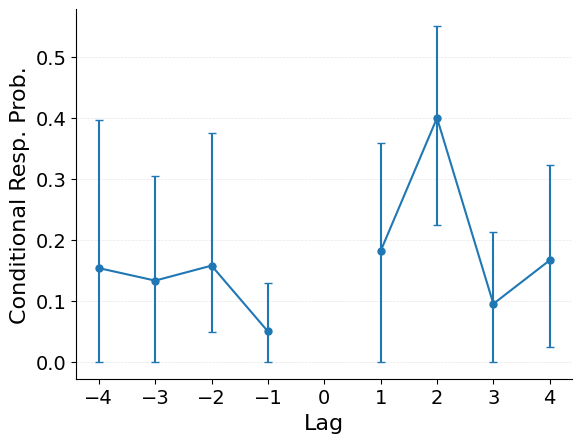

In [20]:
plot_crp(data, trial_mask, response_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)
